In [1]:
import numpy as np
import pandas as pd

from tqdm import tqdm
from config import config
from xgboost import XGBClassifier
from matplotlib import pyplot as plt
from scipy.ndimage import uniform_filter
from joblib import Parallel, delayed
from utils import (
    build_metadata, plot_class_distribution, split_metadata,
    print_split_summary, preprocess_img,
    encode_labels, decode_labels, count_by_class, evaluate_split, sample_pixels
)


In [2]:
def local_mean_std(x, size=3):
    mean = uniform_filter(x, size=size)
    mean_sq = uniform_filter(x * x, size=size)
    var = np.maximum(mean_sq - mean * mean, 0.0)
    std = np.sqrt(var)
    return mean, std

def normalized_diff(a, b, eps=1e-6):
    return (a - b) / (a + b + eps)

def extract_features(img):
    b_raw = img.astype(np.float32)

    blue = b_raw[1]
    green = b_raw[2]
    red = b_raw[3]
    nir = b_raw[7]
    swir1 = b_raw[10]
    swir2 = b_raw[11]

    h, w = red.shape

    bands_mean = np.mean(b_raw, axis=0)
    bands_std = np.std(b_raw, axis=0)
    brightness = np.mean(b_raw[[1, 2, 3]], axis=0)
    visible_std = np.std(b_raw[[1, 2, 3]], axis=0)

    ndvi = normalized_diff(nir, red)
    ndwi = normalized_diff(green, nir)
    mndwi = normalized_diff(green, swir1)
    ndbi = normalized_diff(swir1, nir)
    ndmi = normalized_diff(nir, swir1)
    nbr = normalized_diff(nir, swir2)
    gndvi = normalized_diff(nir, green)

    bsi = ((swir1 + red) - (nir + blue)) / ((swir1 + red) + (nir + blue) + 1e-6)
    savi = 1.5 * (nir - red) / (nir + red + 0.5 + 1e-6)
    evi = 2.5 * (nir - red) / (nir + 6.0 * red - 7.5 * blue + 1.0 + 1e-6)

    msavi_term = (2 * nir + 1) ** 2 - 8 * (nir - red)
    msavi_term = np.maximum(msavi_term, 0.0)
    msavi = (2 * nir + 1 - np.sqrt(msavi_term)) / 2.0

    awei_sh = blue + 2.5 * green - 1.5 * (nir + swir1) - 0.25 * swir2
    awei_nsh = 4.0 * (green - swir1) - (0.25 * nir + 2.75 * swir2)

    nir_red_ratio = nir / (red + 1e-6)
    nir_green_ratio = nir / (green + 1e-6)
    red_green_ratio = red / (green + 1e-6)
    blue_green_ratio = blue / (green + 1e-6)
    swir_ratio = swir1 / (swir2 + 1e-6)
    swir1_red_ratio = swir1 / (red + 1e-6)
    swir1_nir_ratio = swir1 / (nir + 1e-6)

    red_blue_diff = red - blue
    green_red_diff = green - red
    nir_swir1_diff = nir - swir1

    ndvi_mean_3, ndvi_std_3 = local_mean_std(ndvi, size=3)
    ndvi_mean_5, ndvi_std_5 = local_mean_std(ndvi, size=5)
    mndwi_mean_3, mndwi_std_3 = local_mean_std(mndwi, size=3)
    ndbi_mean_3, ndbi_std_3 = local_mean_std(ndbi, size=3)
    nir_mean_3, nir_std_3 = local_mean_std(nir, size=3)
    swir1_mean_3, swir1_std_3 = local_mean_std(swir1, size=3)

    y_coord, x_coord = np.meshgrid(
        np.linspace(0.0, 1.0, h, dtype=np.float32),
        np.linspace(0.0, 1.0, w, dtype=np.float32),
        indexing="ij"
    )

    features = np.concatenate(
        [
            b_raw,
            ndvi[np.newaxis, ...],
            ndwi[np.newaxis, ...],
            mndwi[np.newaxis, ...],
            ndbi[np.newaxis, ...],
            ndmi[np.newaxis, ...],
            nbr[np.newaxis, ...],
            gndvi[np.newaxis, ...],
            bsi[np.newaxis, ...],
            savi[np.newaxis, ...],
            evi[np.newaxis, ...],
            msavi[np.newaxis, ...],
            awei_sh[np.newaxis, ...],
            awei_nsh[np.newaxis, ...],
            brightness[np.newaxis, ...],
            visible_std[np.newaxis, ...],
            bands_mean[np.newaxis, ...],
            bands_std[np.newaxis, ...],
            nir_red_ratio[np.newaxis, ...],
            nir_green_ratio[np.newaxis, ...],
            red_green_ratio[np.newaxis, ...],
            blue_green_ratio[np.newaxis, ...],
            swir_ratio[np.newaxis, ...],
            swir1_red_ratio[np.newaxis, ...],
            swir1_nir_ratio[np.newaxis, ...],
            red_blue_diff[np.newaxis, ...],
            green_red_diff[np.newaxis, ...],
            nir_swir1_diff[np.newaxis, ...],
            ndvi_mean_3[np.newaxis, ...],
            ndvi_std_3[np.newaxis, ...],
            ndvi_mean_5[np.newaxis, ...],
            ndvi_std_5[np.newaxis, ...],
            mndwi_mean_3[np.newaxis, ...],
            mndwi_std_3[np.newaxis, ...],
            ndbi_mean_3[np.newaxis, ...],
            ndbi_std_3[np.newaxis, ...],
            nir_mean_3[np.newaxis, ...],
            nir_std_3[np.newaxis, ...],
            swir1_mean_3[np.newaxis, ...],
            swir1_std_3[np.newaxis, ...],
            x_coord[np.newaxis, ...],
            y_coord[np.newaxis, ...],
        ],
        axis=0,
    )

    feature_names = [f"B{i + 1}" for i in range(b_raw.shape[0])] + [
        "ndvi",
        "ndwi",
        "mndwi",
        "ndbi",
        "ndmi",
        "nbr",
        "gndvi",
        "bsi",
        "savi",
        "evi",
        "msavi",
        "awei_sh",
        "awei_nsh",
        "brightness",
        "visible_std",
        "bands_mean",
        "bands_std",
        "nir_red_ratio",
        "nir_green_ratio",
        "red_green_ratio",
        "blue_green_ratio",
        "swir_ratio",
        "swir1_red_ratio",
        "swir1_nir_ratio",
        "red_blue_diff",
        "green_red_diff",
        "nir_swir1_diff",
        "ndvi_mean_3",
        "ndvi_std_3",
        "ndvi_mean_5",
        "ndvi_std_5",
        "mndwi_mean_3",
        "mndwi_std_3",
        "ndbi_mean_3",
        "ndbi_std_3",
        "nir_mean_3",
        "nir_std_3",
        "swir1_mean_3",
        "swir1_std_3",
        "x_coord",
        "y_coord",
    ]

    return features, feature_names


def process_pair(img_path, mask_path):
    img, mask, confidence, pixel_valid = preprocess_img(img_path, mask_path)
    features, feature_names = extract_features(img)

    valid = pixel_valid & (mask != 0) & (confidence * 100.0 >= config.MIN_CONFIDENCE)
    X = features[:, valid].T.astype(np.float32)
    y = mask[valid].reshape(-1).astype(np.uint8)
    pixel_weight = confidence[valid].reshape(-1).astype(np.float32)

    return X, y, pixel_weight, feature_names


def build_dataset(split_df, n_jobs=-1):
    records = split_df[['img_path', 'mask_path']].to_dict('records')
    results = Parallel(n_jobs=n_jobs, backend='loky')(
        delayed(process_pair)(row['img_path'], row['mask_path'])
        for row in tqdm(records, desc='Building dataset')
    )

    X_parts = []
    y_parts = []
    weight_parts = []
    feature_names = None

    for X, y, pixel_weight, names in results:
        X_parts.append(X)
        y_parts.append(y)
        weight_parts.append(pixel_weight)
        if feature_names is None:
            feature_names = names

    X_all = np.concatenate(X_parts, axis=0)
    y_all = np.concatenate(y_parts, axis=0)
    weight_all = np.concatenate(weight_parts, axis=0)
    return X_all, y_all, weight_all, feature_names

In [3]:
meta = build_metadata(config.DATA_DIR)
train_meta, val_meta, test_meta = split_metadata(meta)

print_split_summary('train', train_meta)
print_split_summary('val', val_meta)
print_split_summary('test', test_meta)

Scanning masks: 100%|██████████| 347/347 [00:00<00:00, 562.47it/s]

[val/test] Falling back to non-stratified split: strata with fewer than 2 samples: ['base']
[train] images: 277
  Unknown  pixels=   10,147 images= 97
  Greenery pixels=11,373,550 images=259
  Sand     pixels=5,542,319 images=229
  Water    pixels=  477,935 images= 43
  Cement   pixels=  749,521 images=215
  strata: {'cement_only__w_0__c_101_1k': 80, 'base__w_0__c_0': 55, 'cement_only__w_0__c_1_100': 52, 'cement_only__w_0__c_1k_10k': 34, 'cement_only__w_0__c_gt_10k': 13, 'water_and_cement__w_1_100__c_101_1k': 6, 'water_only__w_gt_10k__c_0': 5, 'water_and_cement__w_1_100__c_1_100': 5, 'water_and_cement__w_1k_10k__c_101_1k': 4, 'water_and_cement__w_101_1k__c_1k_10k': 4, 'water_and_cement__w_101_1k__c_101_1k': 3, 'water_only__w_101_1k__c_0': 2, 'water_and_cement': 2, 'water_and_cement__w_1k_10k__c_1_100': 2, 'water_and_cement__w_gt_10k__c_1_100': 2, 'water_and_cement__w_1k_10k__c_1k_10k': 2, 'water_and_cement__w_101_1k__c_gt_10k': 2, 'water_and_cement__w_gt_10k__c_1k_10k': 2, 'water_and_c

In [4]:
print(train_meta.head())

  sample_id               img_path                mask_path  total_pixels  \
0       161  data/imgs/img_161.tif  data/masks/mask_161.tif         65536   
1        27   data/imgs/img_27.tif   data/masks/mask_27.tif         65536   
2       173  data/imgs/img_173.tif  data/masks/mask_173.tif         65536   
3        44   data/imgs/img_44.tif   data/masks/mask_44.tif         65536   
4       341  data/imgs/img_341.tif  data/masks/mask_341.tif         65536   

   has_water  has_cement  has_sand  count_0  count_1  count_2  count_3  \
0          0           1         1        0    51646    13131        0   
1          0           0         1        0       56    65480        0   
2          0           1         1        0    64491     1004        0   
3          1           1         0        0    64168        0     1340   
4          0           1         1        0    64013       72        0   

   count_4                              stratum  
0      759           cement_only__w_0__c_1

Building dataset: 100%|██████████| 35/35 [00:00<00:00, 27155.13it/s]


Train full: (18118175, 53) {'Greenery': 11377766, 'Sand': 5510867, 'Water': 478683, 'Cement': 750859}
Val      : (2232828, 53) {'Greenery': 1537498, 'Sand': 566949, 'Water': 23082, 'Cement': 105299}
Test     : (2293690, 53) {'Greenery': 1611254, 'Sand': 583552, 'Water': 10459, 'Cement': 88425}
Train confidence weight range: 0.33000001311302185 1.0
Greenery available=11,377,766 sampled=  400,000
Sand     available=5,510,867 sampled=  400,000
Water    available=  478,683 sampled=  478,683
Cement   available=  750,859 sampled=  450,000
Train sampled: (1728683, 53) {'Greenery': 400000, 'Sand': 400000, 'Water': 478683, 'Cement': 450000}
Val sampled  : (2232828, 53) {'Greenery': 1537498, 'Sand': 566949, 'Water': 23082, 'Cement': 105299}
Test sampled : (2293690, 53) {'Greenery': 1611254, 'Sand': 583552, 'Water': 10459, 'Cement': 88425}


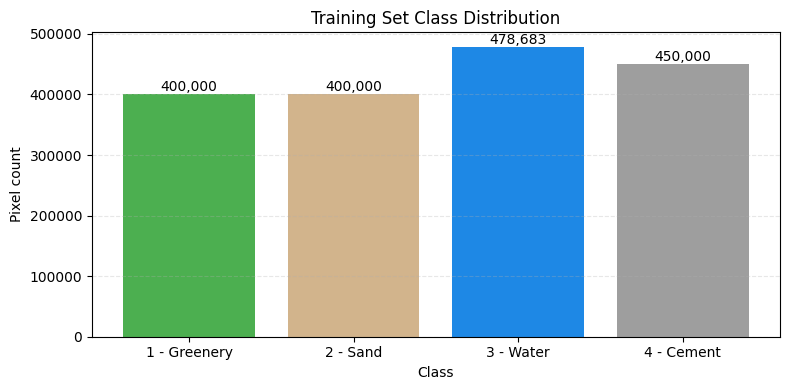

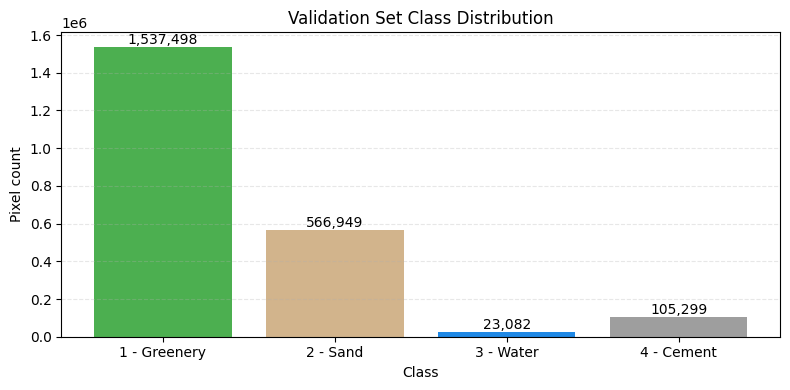

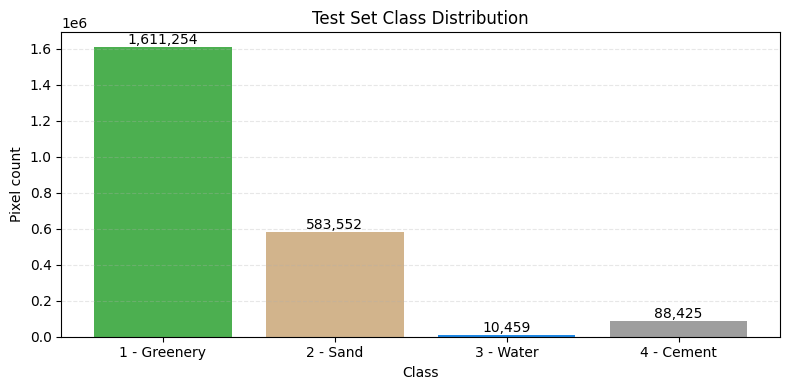

In [5]:
X_train_full, y_train_full, conf_train_full, feature_names = build_dataset(train_meta)
X_val, y_val, _, _ = build_dataset(val_meta)
X_test, y_test, _, _ = build_dataset(test_meta)

print('Train full:', X_train_full.shape, count_by_class(y_train_full))
print('Val      :', X_val.shape, count_by_class(y_val))
print('Test     :', X_test.shape, count_by_class(y_test))
print('Train confidence weight range:', float(conf_train_full.min()), float(conf_train_full.max()))

X_train, y_train, conf_train = sample_pixels(X_train_full, y_train_full, config.TRAIN_CAPS_CLASSIC, conf_train_full)
print('Train sampled:', X_train.shape, count_by_class(y_train))
print('Val sampled  :', X_val.shape, count_by_class(y_val))
print('Test sampled :', X_test.shape, count_by_class(y_test))
plot_class_distribution(y_train, 'Training Set Class Distribution')
plot_class_distribution(y_val, 'Validation Set Class Distribution')
plot_class_distribution(y_test, 'Test Set Class Distribution')

In [6]:
y_train_enc = encode_labels(y_train)
# sample_weight = conf_train.copy()
# sample_weight[y_train == 3] *= config.WATER_WEIGHT_MULTIPLIER
# sample_weight[y_train == 4] *= config.CEMENT_WEIGHT_MULTIPLIER
# print('Weighted classes:', {
#     'Water': config.WATER_WEIGHT_MULTIPLIER,
#     'Cement': config.CEMENT_WEIGHT_MULTIPLIER,
# })

model = XGBClassifier(
    n_estimators=700,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.1,
    reg_lambda=2.0,
    objective="multi:softprob",
    num_class=4,
    eval_metric="mlogloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=config.RANDOM_STATE,
)

model.fit(X_train, y_train_enc)#, sample_weight=sample_weight)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

===== Train =====
              precision    recall  f1-score   support

           1     0.8670    0.8977    0.8821    400000
           2     0.9044    0.8836    0.8939    400000
           3     0.9951    0.9992    0.9972    478683
           4     0.9495    0.9347    0.9420    450000

    accuracy                         0.9322   1728683
   macro avg     0.9290    0.9288    0.9288   1728683
weighted avg     0.9326    0.9322    0.9323   1728683

Confusion Matrix:
 [[359095  26879   1526  12500]
 [ 36339 353447    468   9746]
 [   232     13 478302    136]
 [ 18530  10485    357 420628]]
mIoU: 0.8704779029400075
Per-class IoU: {'Greenery': 0.7890446296536373, 'Sand': 0.8081060503867373, 'Water': 0.9943205677769139, 'Cement': 0.8904403639427413}


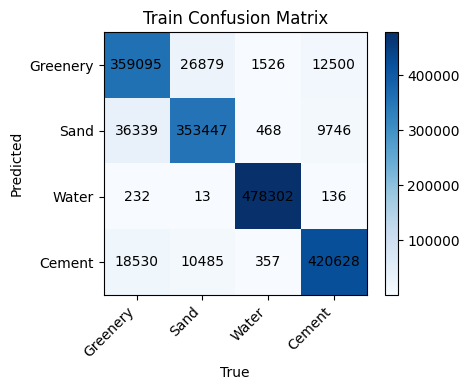

(array([[359095,  26879,   1526,  12500],
        [ 36339, 353447,    468,   9746],
        [   232,     13, 478302,    136],
        [ 18530,  10485,    357, 420628]]),
 0.8704779029400075,
 array([0.78904463, 0.80810605, 0.99432057, 0.89044036]))

In [7]:
evaluate_split("Train", model, X_train, y_train)

===== Validation =====
              precision    recall  f1-score   support

           1     0.9361    0.8849    0.9098   1537498
           2     0.8151    0.8127    0.8139    566949
           3     0.7803    0.8274    0.8032     23082
           4     0.4815    0.8666    0.6190    105299

    accuracy                         0.8651   2232828
   macro avg     0.7532    0.8479    0.7865   2232828
weighted avg     0.8823    0.8651    0.8706   2232828

Confusion Matrix:
 [[1360594   95859    4569   76476]
 [  85850  460766     598   19735]
 [    804    1122   19097    2059]
 [   6295    7541     209   91254]]
mIoU: 0.6600062469005196
Per-class IoU: {'Greenery': 0.8344914002111078, 'Sand': 0.6862038717978886, 'Water': 0.6710591046454424, 'Cement': 0.44827061094763937}


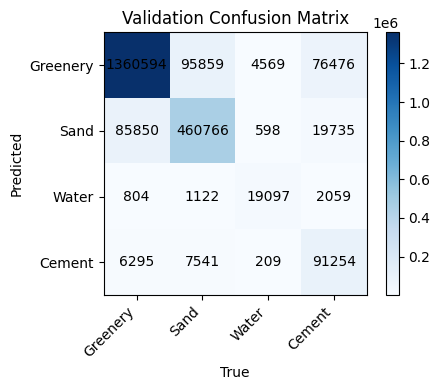

(array([[1360594,   95859,    4569,   76476],
        [  85850,  460766,     598,   19735],
        [    804,    1122,   19097,    2059],
        [   6295,    7541,     209,   91254]]),
 0.6600062469005196,
 array([0.8344914 , 0.68620387, 0.6710591 , 0.44827061]))

In [8]:
evaluate_split('Validation', model, X_val, y_val)

===== Test =====
              precision    recall  f1-score   support

           1     0.9325    0.8487    0.8886   1611254
           2     0.7543    0.8119    0.7820    583552
           3     0.1542    0.6012    0.2455     10459
           4     0.4718    0.8455    0.6056     88425

    accuracy                         0.8381   2293690
   macro avg     0.5782    0.7768    0.6304   2293690
weighted avg     0.8659    0.8381    0.8477   2293690

Confusion Matrix:
 [[1367403  146158   33915   63778]
 [  89380  473786     484   19902]
 [   3732     417    6288      22]
 [   5798    7777      87   74763]]
mIoU: 0.5039740964611865
Per-class IoU: {'Greenery': 0.7995741928844251, 'Sand': 0.6420699711615603, 'Water': 0.13990432751140283, 'Cement': 0.4343478942873576}


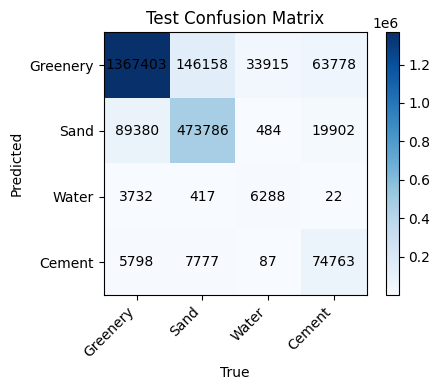

(array([[1367403,  146158,   33915,   63778],
        [  89380,  473786,     484,   19902],
        [   3732,     417,    6288,      22],
        [   5798,    7777,      87,   74763]]),
 0.5039740964611865,
 array([0.79957419, 0.64206997, 0.13990433, 0.43434789]))

In [9]:
evaluate_split('Test', model, X_test, y_test)

In [10]:
importance_df = pd.DataFrame(
    {
        'feature': feature_names,
        'importance': model.feature_importances_,
    }
).sort_values('importance', ascending=False)

display(importance_df.head(20))

,feature,importance
24,awei_nsh,0.337641
11,B12,0.068962
37,green_red_diff,0.068234
41,ndvi_mean_5,0.056450
49,swir1_mean_3,0.050274
34,swir1_red_ratio,0.041023
44,mndwi_std_3,0.039444
31,red_green_ratio,0.027093
30,nir_green_ratio,0.024749
42,ndvi_std_5,0.021086


In [11]:
@np.errstate(divide='ignore', invalid='ignore')
def show_prediction(model, split_df, idx=0):
    row = split_df.iloc[idx]
    img, mask, confidence, pixel_valid = preprocess_img(row['img_path'], row['mask_path'])
    features, _ = extract_features(img)

    valid = pixel_valid & (mask != 0) & (confidence * 100.0 >= config.MIN_CONFIDENCE)
    pred_mask = np.zeros_like(mask, dtype=np.uint8)

    if np.any(valid):
        X = features[:, valid].T.astype(np.float32)
        pred_mask[valid] = decode_labels(model.predict(X))

    rgb = np.transpose(img[[3, 2, 1]], (1, 2, 0))
    rgb = np.clip(rgb * 3.0, 0, 1)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(rgb)
    plt.title('RGB')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(mask, cmap='tab10', vmin=0, vmax=4)
    plt.title('Ground Truth')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask, cmap='tab10', vmin=0, vmax=4)
    plt.title('Prediction')
    plt.axis('off')

    plt.show()

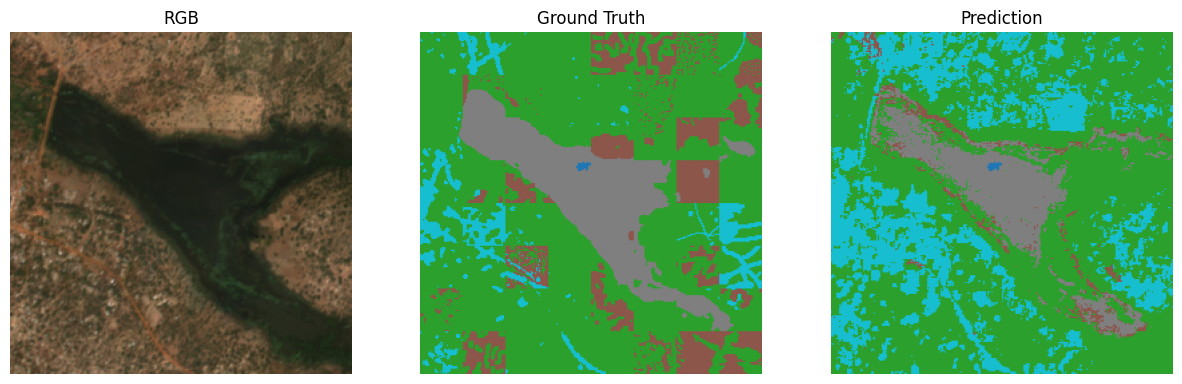

In [12]:
show_prediction(model, test_meta, idx=11)

In [13]:
import pickle

with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)